In [2]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import transform_to_sequence
from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Credit-g](https://www.openml.org/search?type=data&status=active&id=31)

In [3]:
dataset_id = 31
train_data, valid_data, test_data, train_labels, valid_labels, test_labels, _, _ = get_openml_data(dataset_id, transform_func=transform_to_sequence)

In [4]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


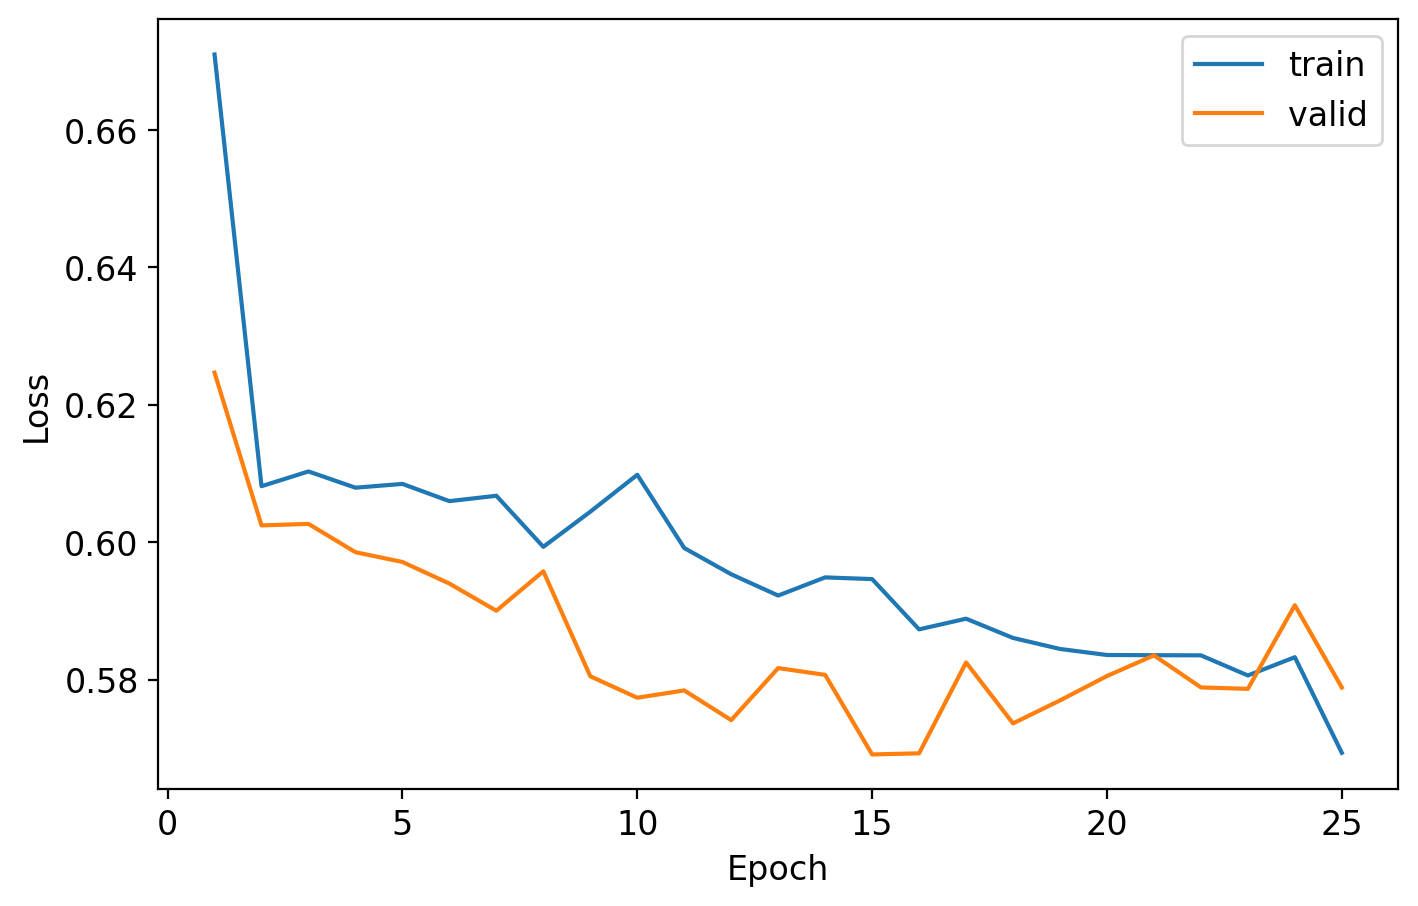

Epoch 25: train loss = 0.5694; valid loss = 0.5789


In [23]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 25, train_loader, valid_loader, criterion, device, scheduler=None)

In [25]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob)

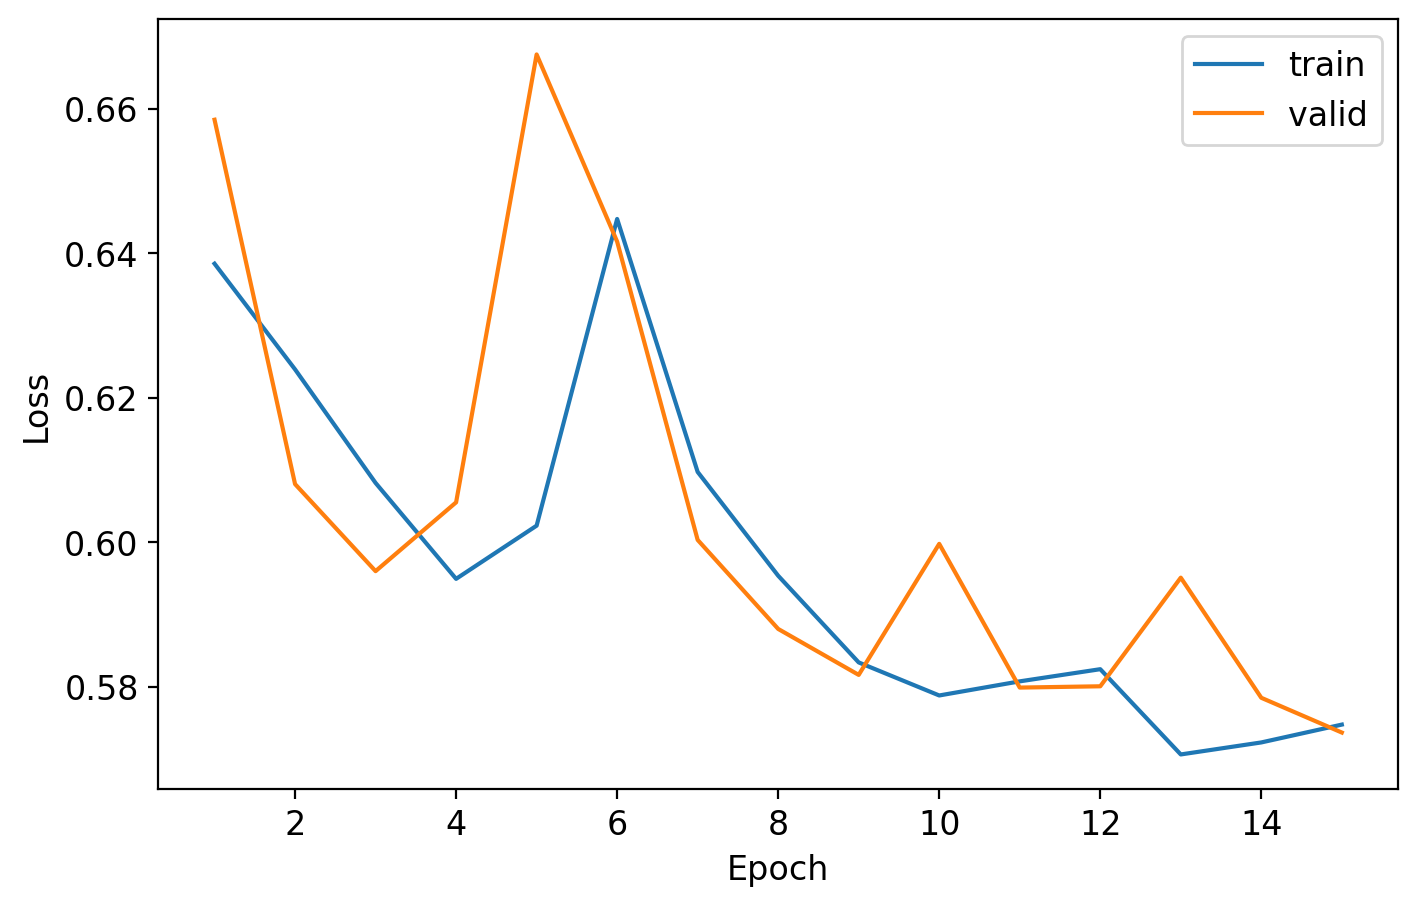

Epoch 15: train loss = 0.5748; valid loss = 0.5737


In [26]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 15, train_loader, valid_loader, criterion, device, scheduler=None)

In [27]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob)

In [28]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.7559±0.0538,0.8575±0.0303,0.7694±0.0434,0.7518±0.0463,1.0000±0.0000
1,Transformer,0.8095±0.0470,0.8244±0.0335,0.7088±0.0477,0.7100±0.0480,0.9854±0.0146
